In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip zipchest_xray.zip

Archive:  zipchest_xray.zip
   creating: chest_xray/
   creating: chest_xray/test/
   creating: chest_xray/test/NORMAL/
  inflating: chest_xray/test/NORMAL/IM-0001-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0003-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0005-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0006-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0007-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0009-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0010-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0011-0001-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0011-0001-0002.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0011-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0013-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0015-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0016-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0017-0001.jpeg  
  inflating: chest_xray/test/NORMAL/IM-0019-0001.jpeg  
  inflating: chest_xray/test/N

In [ ]:
cd chest_xray/

/content/chest_xray


In [ ]:
ls

test/  train/


In [ ]:
cd train

/content/chest_xray/train


In [ ]:
ls

NORMAL/  PNEUMONIA/


In [ ]:
!ls NORMAL | wc -l
!ls PNEUMONIA | wc -l

350
350


In [ ]:
img_size = 224
batch_size = 32
epochs = 15


In [ ]:
train_dir = "/content/zipchest_xray/train"
test_dir = "/content/zipchest_xray/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="binary"
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="binary"
)

Found 700 images belonging to 2 classes.
Found 300 images belonging to 2 classes.


In [ ]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation="relu"))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation="relu"))
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(1, activation="sigmoid"))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_data,
    epochs=epochs,
    validation_data=test_data
)

Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step - accuracy: 0.8010 - loss: 0.4540 - val_accuracy: 0.7500 - val_loss: 0.5023
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 88s 4s/step - accuracy: 0.8630 - loss: 0.3646 - val_accuracy: 0.7767 - val_loss: 0.4391
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 90s 4s/step - accuracy: 0.9009 - loss: 0.2691 - val_accuracy: 0.8100 - val_loss: 0.3994
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 90s 4s/step - accuracy: 0.9143 - loss: 0.2428 - val_accuracy: 0.8467 - val_loss: 0.3605
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 90s 4s/step - accuracy: 0.9066 - loss: 0.2274 - val_accuracy: 0.8267 - val_loss: 0.3933
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step - accuracy: 0.9130 - loss: 0.2514 - val_accuracy: 0.8433 - val_loss: 0.3684
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step - accuracy: 0.9024 - loss: 0.2641 - val_accuracy: 0.8600 - val_loss: 0.3288
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step - accuracy: 0.9247 - loss: 0.2122 - val_accuracy: 0.8633 - val_loss:

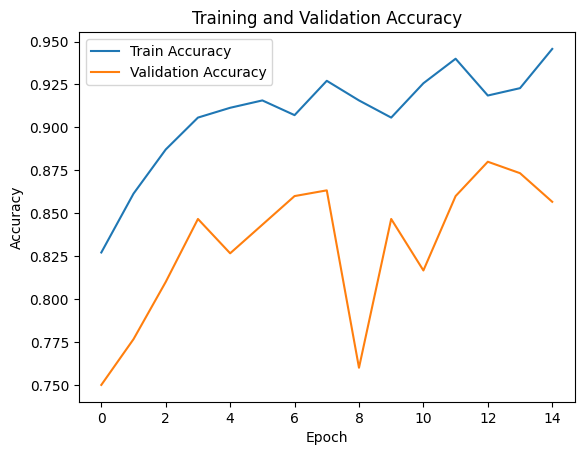

In [ ]:
plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.savefig('/content/drive/MyDrive/accuracy.png')
plt.show()

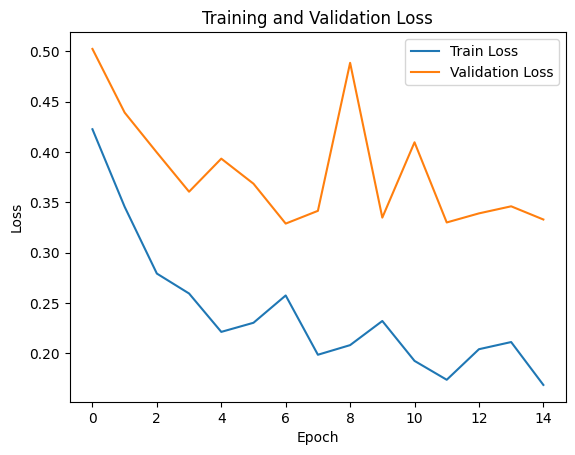

In [ ]:
plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig('/content/drive/MyDrive/loss.png')
plt.show()

In [ ]:
model.save("/content/drive/MyDrive/pneumonia_model_70_30.h5")


In [ ]:
ls /content/drive/MyDrive

 1740036307573.jpg
 accuracy.png
'ALU 1st year mess fees'/
'ALU 2nd year mess fees'/
'ALU docs'/
 ALU.pdf
 chest_xray/
'Colab Notebooks'/
 confusion_matrix.png
'Copy of pneumonia_cnn_model.h5'
 CUTNPGCT0001988_1715440566.pdf
'DocScanner Aug 5, 2023 4-59 PM.jpg'
 gromacs_complete.tar.gz
 IMG-20230822-WA0003.jpg
'IMG_20240828_212336_792 (1)-compressed.jpeg'
 IMG_20241021_145332_445.jpg
 IMG-20241021-WA0006.jpg
 IMG_20241101_204847_079.jpg
 IMG_20241101_204937_036.jpg
 IMG_20241101_205032_266.jpg
 IMG_20241101_205117_937.jpg
 IMG_20241101_205157_607.jpg
 IMG_20241101_205250_181.jpg
 IMG_20241101_205325_489.jpg
 IMG_20241101_205404_521.jpg
 IMG_20241101_205454_230.jpg
 IMG_20241101_205547_303.jpg
 IMG_20241101_205802_394.jpg
 IMG_20241101_205844_893.jpg
 IMG_20241101_210031_098.jpg
 IMG_20241101_210129_174.jpg
 IMG_20241101_210226_875.jpg
 IMG_20241101_210401_041.jpg
 IMG_20241101_210501_921.jpg
 IMG_20241101_210527_861.jpg
 IMG_20241101_210556_770.jpg
 IMG_20241101_210623_927.jpg
 IMG_202

In [ ]:
import os
os.path.exists('/content/drive/MyDrive/pneumonia_model_70_30.h5')

True

In [ ]:
mkdir -p /content/drive/MyDrive/models

In [ ]:
ls /content/drive/MyDrive/models

pneumonia_cnn_model.h5  pneumonia_model_70_30.h5


In [ ]:
model.save('/content/drive/MyDrive/models/pneumonia_model_new.h5')

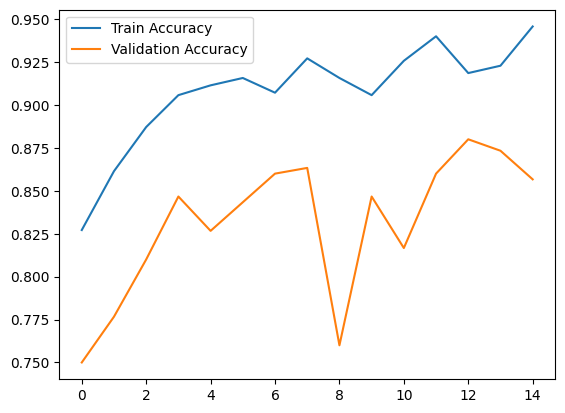

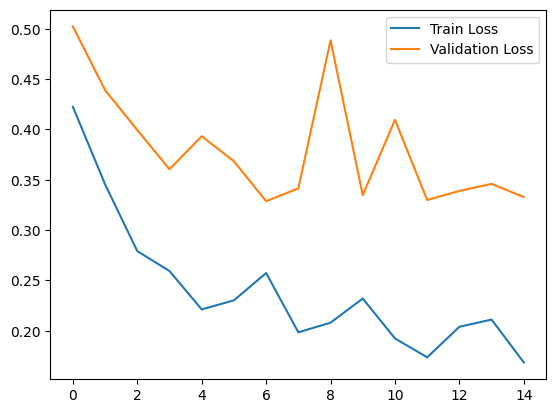

In [ ]:
plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.show()


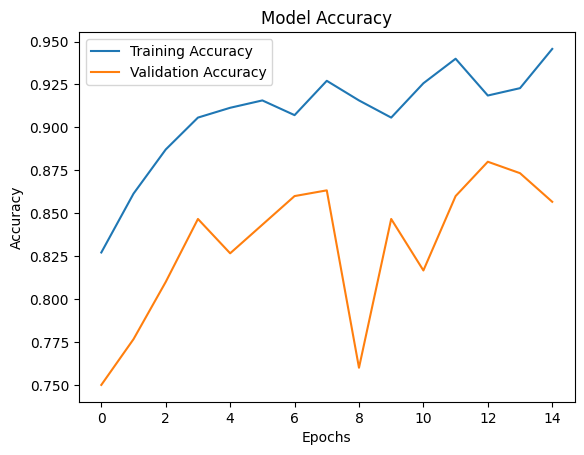

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Save image
plt.savefig('/content/drive/MyDrive/models/accuracy_70_30.png')
plt.show()


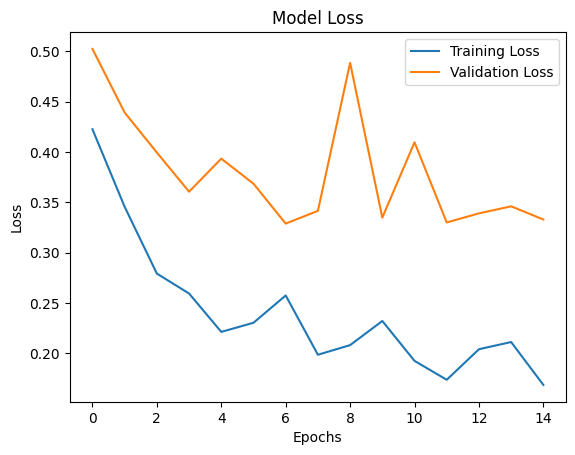

In [ ]:
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

# Save image
plt.savefig('/content/drive/MyDrive/models/loss_70_30.png')
plt.show()


In [ ]:
plt.savefig('/content/accuracy_70_30.png')
plt.savefig('/content/loss_70_30.png')

<Figure size 640x480 with 0 Axes>

In [ ]:
from tensorflow.keras.models import load_model
model= load_model('/content/drive/MyDrive/models/pneumonia_model_70_30.h5')

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
from tensorflow.keras.models import load_model
model= load_model('/content/drive/MyDrive/models/pneumonia_model_70_30.h5')

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/chest_xray/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


Found 300 images belonging to 2 classes.


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(test_generator)
y_pred_classes = (y_pred > 0.5).astype("int32")

# Confusion matrix
cm = confusion_matrix(test_generator.classes, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Normal', 'Pneumonia'])

plt.figure(figsize=(6,6))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.savefig('/content/confusion_matrix.png')
plt.show()


NameError: name 'test_generator' is not defined

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(test_generator.classes,
                               y_pred_classes,
                               target_names=['Normal','Pneumonia'])
print(report)

# Save report as text file
with open('/content/classification_report.txt', 'w') as f:
    f.write(report)

              precision    recall  f1-score   support

      Normal       0.85      0.87      0.86       150
   Pneumonia       0.86      0.85      0.86       150

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.86      0.86      0.86       300



In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/chest_xray/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 300 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 737ms/step


<Figure size 600x600 with 0 Axes>

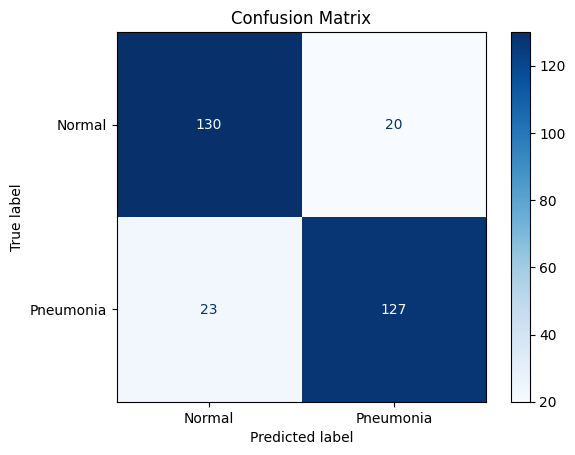

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(test_generator)
y_pred_classes = (y_pred > 0.5).astype("int32")

# Confusion matrix
cm = confusion_matrix(test_generator.classes, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Normal', 'Pneumonia'])

plt.figure(figsize=(6,6))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.savefig('/content/confusion_matrix.png')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(test_generator.classes,
                               y_pred_classes,
                               target_names=['Normal','Pneumonia'])
print(report)

# Save report as text file
with open('/content/classification_report.txt', 'w') as f:
    f.write(report)


              precision    recall  f1-score   support

      Normal       0.88      0.87      0.88       150
   Pneumonia       0.87      0.88      0.88       150

    accuracy                           0.88       300
   macro avg       0.88      0.88      0.88       300
weighted avg       0.88      0.88      0.88       300



In [ ]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.output.shape)

0 conv2d (None, 222, 222, 32)
1 max_pooling2d (None, 111, 111, 32)
2 conv2d_1 (None, 109, 109, 64)
3 max_pooling2d_1 (None, 54, 54, 64)
4 conv2d_2 (None, 52, 52, 128)
5 max_pooling2d_2 (None, 26, 26, 128)
6 flatten (None, 86528)
7 dense (None, 128)
8 dropout (None, 128)
9 dense_1 (None, 1)
